In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets

In [3]:
data = pd.read_csv("data/train.csv")
X = data.drop(columns='target')
y = data['target']
X, y

(        area  perimeter  major_axis  minor_axis  eccentricity   eqdiasq  \
 0      75516  1731.4840    411.7352    245.7620        0.8023  310.0806   
 1      98903  1374.4370    477.2451    269.7676        0.8249  354.8622   
 2      84746  1311.1570    482.7735    235.9040        0.8725  328.4843   
 3      98184  1463.1680    434.3769    292.6472        0.7390  353.5700   
 4      94170  1267.7271    440.1109    278.4162        0.7745  346.2672   
 ...      ...        ...         ...         ...           ...       ...   
 1283  103151  2145.1340    499.3782    280.9169        0.8268  362.4030   
 1284   54322  1569.1990    363.6869    217.1759        0.8021  262.9922   
 1285   69080  1713.4390    434.3565    213.7013        0.8706  296.5727   
 1286   83490  1161.5470    448.3226    251.6644        0.8276  326.0410   
 1287   63091  1058.6920    412.6924    199.5693        0.8753  283.4254   
 
       solidity  convex_area  extent  aspect_ratio  roundness  compactness  \
 0      

# Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
encoder = LabelEncoder()
y = encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Principal Component Analysis

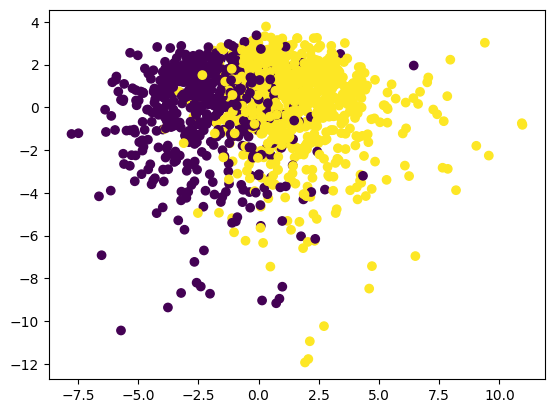

In [6]:
from sklearn.decomposition import PCA

model_PCA = PCA(n_components=3)
X_pca = model_PCA.fit_transform(X)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y,cmap='viridis')
plt.show()

# Import Metrics

In [7]:
from sklearn.metrics import accuracy_score,log_loss

def count_error(y_true,y_pred):
    err = 0
    for i in range(len(y_true)):
        if(y_true[i]!=y_pred[i]): 
            err+=1
    return err

# Training

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

In [34]:
list_model = np.array([]) 
str_model = np.array(['DecisioneTreeClassifier','RandomForestClassifier','LogisticRegression','SVC','KNeighborsClassifier','MLPClassifier'])

list_model = np.append(list_model, DecisionTreeClassifier(max_depth=1000, criterion='gini',random_state=42))
list_model = np.append(list_model, RandomForestClassifier(n_estimators=100, max_depth=1000, criterion='gini',random_state=42))
list_model = np.append(list_model, LogisticRegression(max_iter=1000,random_state=42))
list_model = np.append(list_model, SVC(kernel='rbf', probability=True, degree=3,random_state=42))
list_model = np.append(list_model, KNeighborsClassifier(n_neighbors=10))
list_model = np.append(list_model, MLPClassifier(hidden_layer_sizes=(64, 128, 256, 128), learning_rate_init=0.005, max_iter=10000, tol=0.00001, random_state=42, alpha=0.01, epsilon=1e-06))

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
accuracy_array = np.array([])

for i in range(len(list_model)):
    print(f"Modello = {str_model[i]}")
    start_time = time.time()
    print(list_model[i])
    list_model[i].fit(X_train,y_train)

    pred_Train = list_model[i].predict(X_train)
    pred_proba_Train = list_model[i].predict_proba(X_train)
    pred_Test = list_model[i].predict(X_test)
    pred_proba_Test = list_model[i].predict_proba(X_test)
    
    acc_test = accuracy_score(y_test, pred_Test)
    accuracy_array = np.append(accuracy_array,acc_test)
    print(f"Accuracy train = {accuracy_score(y_train, pred_Train)},loss train = {log_loss(y_train, pred_proba_Train)}, errors train = {count_error(y_train, pred_Train)} out of {len(y_train)}")
    print(f"Accuracy test = {acc_test},loss test = {log_loss(y_test, pred_proba_Test)}, errors test = {count_error(y_test, pred_Test)} out of {len(y_test)}")
    print(f"Training time = {time.time()-start_time}s")
    print()    

Modello = DecisioneTreeClassifier
DecisionTreeClassifier(max_depth=1000, random_state=42)
Accuracy train = 1.0,loss train = 2.2204460492503136e-16, errors train = 0 out of 966
Accuracy test = 0.8198757763975155,loss test = 6.492335082511785, errors test = 58 out of 322
Training time = 0.019015073776245117s

Modello = RandomForestClassifier
RandomForestClassifier(max_depth=1000, random_state=42)
Accuracy train = 1.0,loss train = 0.0773296124797433, errors train = 0 out of 966
Accuracy test = 0.860248447204969,loss test = 0.5541425744451574, errors test = 45 out of 322
Training time = 0.35793638229370117s

Modello = LogisticRegression
LogisticRegression(max_iter=1000, random_state=42)
Accuracy train = 0.8674948240165632,loss train = 0.3039828278564355, errors train = 128 out of 966
Accuracy test = 0.8571428571428571,loss test = 0.373699044727123, errors test = 46 out of 322
Training time = 0.018004417419433594s

Modello = SVC
SVC(probability=True, random_state=42)
Accuracy train = 0.8788

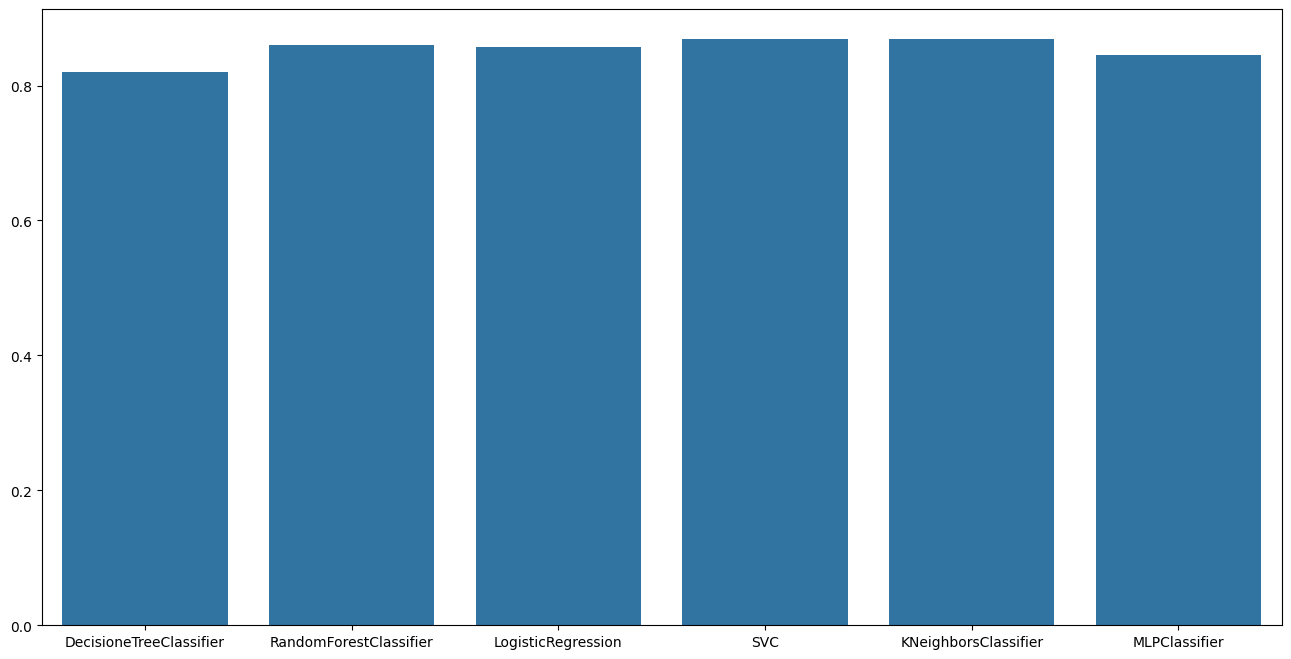

In [27]:
plt.figure(figsize=(16,8))
sns.barplot(x=str_model,y=accuracy_array)
plt.show()